<p>Run cells in order from a fresh Julia 1.12 kernel. The supplied setup
below selects the course environment; dependencies must already be
installed. <a href="../README.md">Setup and index</a> · <a
href="../solutions-en.md">Worked solutions</a>.</p>


In [1]:
# Supplied notebook setup: activate the course environment.
import Pkg
Pkg.activate(normpath(joinpath(pwd(), "..", "..")); io = devnull)
println("Course environment activated.")

Course environment activated.


<h1
id="total-internal-reflection-from-a-ray-decision-to-a-wave-field">2.
Total internal reflection: from a ray decision to a wave field</h1>
<p><strong>Optional self-study · approximately 100–140 minutes.</strong>
This chapter is unexamined, is not a prerequisite, and is separate from
the extra-credit complex-phasor bonus. We assume scalar arithmetic,
degree trigonometry, and <code dir="ltr" style="unicode-bidi:isolate">if</code> branches. We explain the
supplied sampling and plotting expressions locally. Wave vectors,
evanescent decay, and numerical aperture are new enrichment
concepts.</p>
<h2 id="can-light-reach-a-boundary-and-stay-inside">2.1 Can light reach
a boundary and stay inside?</h2>
<p>A swimming pool viewed from below can behave like a mirror at
sufficiently oblique angles. Optical fibers use a related phenomenon to
guide light. A simple inequality classifies a ray, but the interesting
physics is why the inequality appears and what happens to the
electromagnetic field on the other side.</p>
<blockquote class="physics" style="background:#f4eff9;border:0;border-inline-start:5px solid #8c69ab;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>Physics — our interface model.</strong> Two homogeneous,
isotropic, transparent, nonmagnetic media meet at a plane. Their
positive real refractive indices are <span
class="math inline">\(n_1\)</span> and <span
class="math inline">\(n_2\)</span>, with phase speeds <span
class="math inline">\(c/n_1\)</span> and <span
class="math inline">\(c/n_2\)</span>. Light is monochromatic, the
interface is flat on wavelength scales, and both media are initially
treated as infinite half-spaces. Incidence angle <span
class="math inline">\(\theta_i\)</span> and transmission angle <span
class="math inline">\(\theta_t\)</span> are measured from the normal,
between <span class="math inline">\(0\)</span> and <span
class="math inline">\(90^\circ\)</span>. Medium 1 is incident-side <span
class="math inline">\(z&lt;0\)</span>; medium 2 is <span
class="math inline">\(z&gt;0\)</span>. Absorption, roughness, and finite
nearby boundaries need a richer model. At normal incidence the ray
remains normal.</p>
</blockquote>
<h2 id="deriving-snells-law-from-matching-phase">2.2 Deriving Snell’s
law from matching phase</h2>
<p>A plane wave has phase <span
class="math inline">\(\mathbf{k}\cdot\mathbf{r}-\omega t\)</span>, where
<span class="math inline">\(\mathbf{k}\)</span> points in the
propagation direction and has magnitude <span
class="math inline">\(k=n\omega/c\)</span>. This vector counts how
rapidly phase changes per unit distance. A crest travels while its phase
stays constant.</p>
<p>The electric and magnetic boundary conditions must hold at every
position along the interface and every time. Incident, reflected, and
transmitted waves must therefore have the same frequency and the same
wave-vector component parallel to the surface. Otherwise their relative
phases would change along the boundary and a matching condition at one
point would fail elsewhere. Consequently,</p>
<p><span class="math display">\[k_1\sin\theta_i=k_2\sin\theta_t,
\qquad \boxed{n_1\sin\theta_i=n_2\sin\theta_t.}\]</span></p>
<p>The reflected wave stays in medium 1 and reverses its normal
wave-vector component, giving equality of reflection and incidence
angles. Snell’s law specifies direction, not the fractions of optical
power reflected and transmitted; those require the amplitude boundary
conditions (Fresnel coefficients).</p>
<blockquote class="mathematics" style="background:#eff6ee;border:0;border-inline-start:5px solid #5f9763;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>Mathematics — when a real angle exists.</strong> For <span
class="math inline">\(0\leq\theta_i&lt;90^\circ\)</span>, define <span
class="math inline">\(q=(n_1/n_2)\sin\theta_i\)</span>. A propagating
transmitted ray requires <span class="math inline">\(q\leq1\)</span>. If
<span class="math inline">\(n_1&gt;n_2\)</span>, the boundary is <span
class="math inline">\(\theta_c=\arcsin(n_2/n_1)\)</span>. For <span
class="math inline">\(\theta_i&gt;\theta_c\)</span> there is total
internal reflection (TIR); at equality the transmitted direction is
grazing. If <span class="math inline">\(n_1\leq n_2\)</span>, no
incidence angle below <span class="math inline">\(90^\circ\)</span>
gives TIR in this ideal model.</p>
</blockquote>
<h2 id="turning-the-law-into-a-julia-decision">2.3 Turning the law into
a Julia decision</h2>
<p>The setup selects the installed graphics backend and formatted
numerical output. A placeholder such as <code dir="ltr" style="unicode-bidi:isolate">%.3f</code> prints three
decimal places. <code dir="ltr" style="unicode-bidi:isolate">println</code> writes a message deliberately; a
notebook otherwise displays the final value automatically.</p>


In [2]:
using Plots
using Printf
gr()
default(size = (760, 420), linewidth = 2, legend = :topright)
println("Optics ready; angles measured from the interface normal unless stated.")

Optics ready; angles measured from the interface normal unless stated.


<p>For glass with <span class="math inline">\(n_1=1.50\)</span> and air
with <span class="math inline">\(n_2=1.00\)</span>, predict whether
<span class="math inline">\(50^\circ\)</span> produces a real
transmitted angle. <code dir="ltr" style="unicode-bidi:isolate">sind</code> accepts degrees and
<code dir="ltr" style="unicode-bidi:isolate">asind</code> returns degrees. We calculate <span
class="math inline">\(q\)</span> before calling the inverse sine, so an
impossible angle never reaches that operation.</p>


In [3]:
n1 = 1.50
n2 = 1.00
theta_i_deg = 50.0
q = n1 * sind(theta_i_deg) / n2
@printf("sin(theta_t) requested by Snell: %.6f\n", q)
if q > 1.0
    println("total internal reflection: no propagating transmitted ray")
elseif q == 1.0
    println("critical angle: transmitted ray is grazing")
else
    theta_t_deg = asind(q)
    @printf("refracted ray: theta_t = %.3f degrees\n", theta_t_deg)
end
theta_c_deg = asind(n2 / n1)
@printf("critical angle = %.3f degrees\n", theta_c_deg)

sin(theta_t) requested by Snell: 1.149067
total internal reflection: no propagating transmitted ray


critical angle = 41.810 degrees


<p>The critical angle is about <span
class="math inline">\(41.81^\circ\)</span>, below the chosen incidence.
An inverse-sine domain error here would signal that we attempted the
wrong physical branch; it should not be “fixed” by forcing every <span
class="math inline">\(q&gt;1\)</span> to one.</p>
<blockquote class="check" style="background:#fff4e7;border:0;border-inline-start:5px solid #d98538;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>Check — a numerical boundary has a physical
uncertainty.</strong> The explicit <code dir="ltr" style="unicode-bidi:isolate">q == 1.0</code> branch names
the ideal mathematical boundary. A value constructed through
trigonometric arithmetic may fall slightly to either side because of
rounding. For measurements close to critical incidence, propagate the
angle and index uncertainty and report “near critical” when the range
straddles one. Rounding all angles first or adding a broad numerical
tolerance would move a real physical threshold.</p>
</blockquote>
<p>Now lower the incidence to <span
class="math inline">\(30^\circ\)</span>. We expect a transmitted angle
larger than incidence because the second medium has smaller index. The
picture below shows <strong>paths</strong>, not power fractions; the
incident path is traversed toward the origin, while the other paths are
traversed away from it.</p>
<blockquote class="julia" style="background:#f0f1f3;border:0;border-inline-start:5px solid #858a93;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>Julia — drawing sampled paths.</strong> <code dir="ltr" style="unicode-bidi:isolate">range</code>
supplies evenly spaced values of a distance parameter. <code dir="ltr" style="unicode-bidi:isolate">.*</code>
scales each entry; arrays in square brackets give explicit endpoint
coordinates. <code dir="ltr" style="unicode-bidi:isolate">plot</code> creates a figure and <code dir="ltr" style="unicode-bidi:isolate">plot!</code>
adds lines. <code dir="ltr" style="unicode-bidi:isolate">aspect_ratio = :equal</code> gives the same visual
length to equal horizontal and vertical distances. Colours and labels
distinguish the three ray paths.</p>
</blockquote>


30-degree incidence gives 48.590-degree transmission


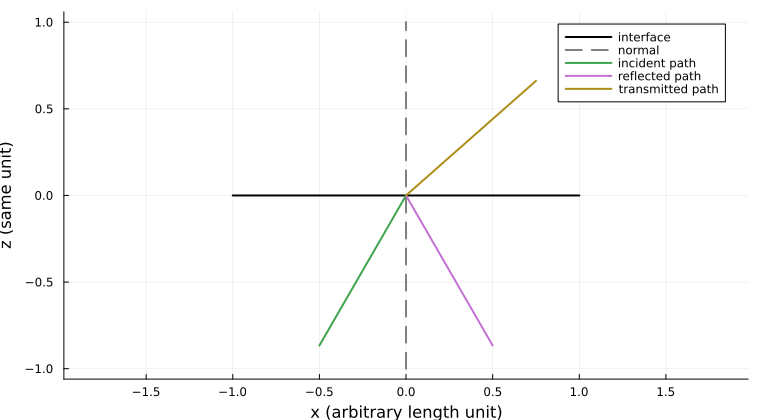

In [4]:
theta_i_deg = 30.0
theta_t_deg = asind(n1 * sind(theta_i_deg) / n2)
@printf("30-degree incidence gives %.3f-degree transmission\n", theta_t_deg)
s = range(0.0, 1.0; length = 100)
p_rays = plot([-1.0, 1.0], [0.0, 0.0]; color = :black, label = "interface",
    xlabel = "x (arbitrary length unit)", ylabel = "z (same unit)", aspect_ratio = :equal)
plot!(p_rays, [0.0, 0.0], [-1.0, 1.0]; linestyle = :dash, color = :gray, label = "normal")
plot!(p_rays, -s .* sind(theta_i_deg), -s .* cosd(theta_i_deg); label = "incident path")
plot!(p_rays, s .* sind(theta_i_deg), -s .* cosd(theta_i_deg); label = "reflected path")
plot!(p_rays, s .* sind(theta_t_deg), s .* cosd(theta_t_deg); label = "transmitted path")
display(p_rays)

<p>The ray bends away from the normal as expected. Some reflection
generally occurs even below the critical angle. Our ray drawing does not
calculate that reflected fraction and therefore cannot establish
transmission efficiency.</p>
<h2 id="beyond-the-ray-picture-an-evanescent-field">2.4 Beyond the ray
picture: an evanescent field</h2>
<p>“No transmitted ray” does not mean “no field in medium 2.” The
parallel wave number is fixed by the incident wave, while the magnitude
of the wave vector in medium 2 must satisfy</p>
<p><span
class="math display">\[k_{2z}^2+k_\parallel^2=\left(\frac{n_2\omega}{c}\right)^2.\]</span></p>
<p>Substitution gives</p>
<p><span class="math display">\[k_{2z}^2=\left(\frac\omega c\right)^2
\left(n_2^2-n_1^2\sin^2\theta_i\right).\]</span></p>
<p>Above the critical angle the right side is negative. Write <span
class="math inline">\(k_{2z}=i\kappa\)</span>, with <span
class="math inline">\(i^2=-1\)</span> and</p>
<p><span
class="math display">\[\kappa=\frac{2\pi}{\lambda_0}\sqrt{n_1^2\sin^2\theta_i-n_2^2},
\qquad \lambda_0=\frac{2\pi c}{\omega}.\]</span></p>
<p>Complex notation is a bookkeeping tool: the physical electric field
is the real part. With the time convention <span
class="math inline">\(e^{-i\omega t}\)</span>, a representative
transmitted component has the form</p>
<p><span
class="math display">\[E(x,z,t)=\operatorname{Re}\left[E_0e^{ik_\parallel
x-i\omega t}e^{-\kappa z}\right].\]</span></p>
<p>We choose the decaying solution; a field growing without bound as
<span class="math inline">\(z\to\infty\)</span> is incompatible with
this illumination problem. The amplitude falls by <span
class="math inline">\(e^{-1}\)</span> at penetration depth <span
class="math inline">\(d=1/\kappa\)</span>. Its squared magnitude falls
by <span class="math inline">\(e^{-1}\)</span> at <span
class="math inline">\(d/2\)</span>.</p>
<blockquote class="physics" style="background:#f4eff9;border:0;border-inline-start:5px solid #8c69ab;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>Physics — decay is not absorption.</strong> An evanescent
wave in a lossless second half-space has no net time-averaged energy
flux normal to the interface, even though its field is nonzero. Squared
amplitude is not a transmitted normal power in this situation. Energy
conservation gives total reflection for the ideal interface. A second
high-index medium placed within the decay distance can allow frustrated
TIR, transferring power across the gap; then the infinite-half-space
assumption fails.</p>
</blockquote>
<p>We use vacuum wavelength <span class="math inline">\(\lambda_0=0.55\
\mu\)</span>m. Expressing wavelength and distance in micrometres makes
<span class="math inline">\(\kappa\)</span> come out in inverse
micrometres. <code dir="ltr" style="unicode-bidi:isolate">sqrt.</code> and <code dir="ltr" style="unicode-bidi:isolate">exp.</code> act entry by
entry. The log-scaled depth axis reveals the rapid change near critical
incidence. We start slightly above the threshold because exactly at it
the exponential decay constant is zero.</p>


50 degrees: amplitude penetration depth = 0.1547 micrometres


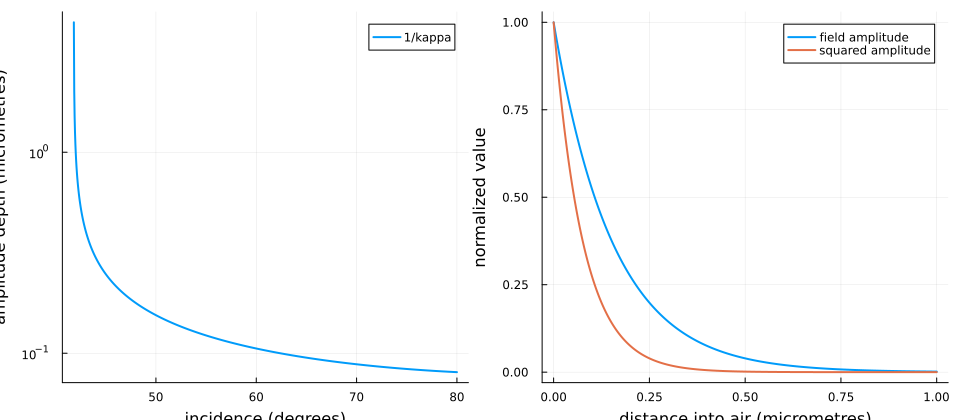

In [5]:
lambda0_um = 0.55
theta_deg = range(theta_c_deg + 0.01, 80.0; length = 1000)
kappa_per_um = (2pi / lambda0_um) .* sqrt.(n1^2 .* sind.(theta_deg) .^ 2 .- n2^2)
depth_um = 1.0 ./ kappa_per_um
kappa50 = (2pi / lambda0_um) * sqrt(n1^2 * sind(50.0)^2 - n2^2)
@printf("50 degrees: amplitude penetration depth = %.4f micrometres\n", 1 / kappa50)
z_um = range(0.0, 1.0; length = 501)
p_depth = plot(theta_deg, depth_um; label = "1/kappa", xlabel = "incidence (degrees)",
    ylabel = "amplitude depth (micrometres)", yscale = :log10)
p_field = plot(z_um, exp.(-kappa50 .* z_um); label = "field amplitude",
    xlabel = "distance into air (micrometres)", ylabel = "normalized value")
plot!(p_field, z_um, exp.(-2 .* kappa50 .* z_um); label = "squared amplitude")
display(plot(p_depth, p_field; layout = (1, 2), size = (960, 420)))

<p>At <span class="math inline">\(50^\circ\)</span> the amplitude depth
is a small fraction of a micrometre. Approaching critical incidence from
above sends <span class="math inline">\(\kappa\to0\)</span> and <span
class="math inline">\(d\to\infty\)</span> in this ideal plane-wave
calculation. A finite beam or finite geometry need not realize an
arbitrarily large penetration depth. Increasing the angle increases
<span class="math inline">\(\kappa\)</span> and tightens
confinement.</p>
<h2 id="from-a-flat-boundary-to-an-ideal-fiber">2.5 From a flat boundary
to an ideal fiber</h2>
<p>Consider a straight core of index <span class="math inline">\(n_{\rm
core}\)</span> surrounded by lower-index cladding <span
class="math inline">\(n_{\rm clad}\)</span>. A ray in a plane through
the axis is called <strong>meridional</strong>. Let <span
class="math inline">\(\alpha\)</span> be its angle to the axis. Its
incidence at a straight side wall is <span
class="math inline">\(90^\circ-|\alpha|\)</span>. TIR requires</p>
<p><span class="math display">\[|\alpha|&lt;\alpha_{\max}=\arccos(n_{\rm
clad}/n_{\rm core}).\]</span></p>
<p>At the flat entrance face, its normal is the fiber axis. For an
external medium of index <span class="math inline">\(n_0\)</span>, Snell
gives <span class="math inline">\(n_0\sin\theta_0=n_{\rm
core}\sin\alpha\)</span>. At the limiting internal angle,</p>
<p><span class="math display">\[n_0\sin\theta_{0,\max}=\sqrt{n_{\rm
core}^2-n_{\rm clad}^2}
\equiv\mathrm{NA}.\]</span></p>
<p>The dimensionless quantity NA is the <strong>numerical
aperture</strong>. If <span
class="math inline">\(\mathrm{NA}/n_0&gt;1\)</span>, the ray model’s
angular bound saturates at <span
class="math inline">\(90^\circ\)</span>; the inverse sine must not be
asked to exceed its domain. Unlike clamping an impossible transmitted
ray, this <code dir="ltr" style="unicode-bidi:isolate">min</code> represents the explicit limit of available
external directions.</p>


In [6]:
n_core = 1.48
n_clad = 1.46
n_external = 1.0
NA = sqrt(n_core^2 - n_clad^2)
alpha_max_deg = acosd(n_clad / n_core)
theta_accept_deg = asind(min(1.0, NA / n_external))
@printf("NA = %.4f; internal axial limit = %.3f degrees\n", NA, alpha_max_deg)
@printf("External acceptance half-angle = %.3f degrees\n", theta_accept_deg)
alpha_deg = 5.0
theta_wall_deg = 90.0 - alpha_deg
@printf("Chosen axial angle = %.1f; wall incidence = %.1f degrees\n", alpha_deg, theta_wall_deg)
println("Guided by strict TIR? ", theta_wall_deg > asind(n_clad / n_core))

NA = 0.2425; internal axial limit = 9.430 degrees
External acceptance half-angle = 14.033 degrees
Chosen axial angle = 5.0; wall incidence = 85.0 degrees
Guided by strict TIR? true


<p>The accepted cone is narrow for weak index contrast. A <span
class="math inline">\(5^\circ\)</span> internal axial angle is guided
for these indices. Be careful: this angle is not the incidence angle at
the wall, nor the external launch angle.</p>
<h2 id="tracing-many-reflections-without-hidden-mechanics">2.6 Tracing
many reflections without hidden mechanics</h2>
<p>Let the transverse core width be <span
class="math inline">\(w=0.1\)</span> mm and launch from <span
class="math inline">\(y=0\)</span> at <span
class="math inline">\(x=0\)</span>. Between wall hits <span
class="math inline">\(dy/dx=\tan\alpha\)</span>. The first hit occurs at
<span class="math inline">\(x=w/(2\tan\alpha)\)</span> for positive
<span class="math inline">\(\alpha\)</span>; later hits are separated by
<span class="math inline">\(w/\tan\alpha\)</span>. Reflection reverses
the transverse direction and preserves the axial direction.</p>
<p>An unfolded line <span class="math inline">\(u=x\tan\alpha\)</span>
passes through mirrored copies of the core. Folding it back produces a
triangle wave:</p>
<p><span class="math display">\[y(x)=\frac
w2-\left|\left[(u+w/2)\bmod(2w)\right]-w\right|.\]</span></p>
<p>Here <span class="math inline">\(a\bmod b\)</span> means the
remainder in <span class="math inline">\([0,b)\)</span> for <span
class="math inline">\(b&gt;0\)</span>. On the initial interval <span
class="math inline">\(0\leq u\leq w/2\)</span>, substitution gives <span
class="math inline">\(y=u\)</span>; the next interval reverses the
slope. Julia’s <code dir="ltr" style="unicode-bidi:isolate">mod.</code> applies this remainder to every
coordinate and <code dir="ltr" style="unicode-bidi:isolate">abs.</code> supplies the fold. Thus no loop or
hidden reflection routine is needed.</p>


First wall hit: 0.5715 mm
Axial distance between later wall hits: 1.1430 mm


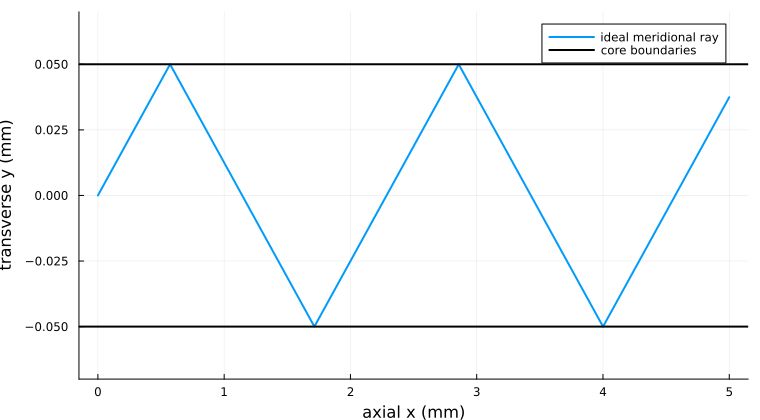

In [7]:
width_mm = 0.1
length_mm = 5.0
x_mm = range(0.0, length_mm; length = 5001)
unfolded_mm = x_mm .* tand(alpha_deg)
y_mm = width_mm / 2 .- abs.(mod.(unfolded_mm .+ width_mm / 2, 2 * width_mm) .- width_mm)
@printf("First wall hit: %.4f mm\n", width_mm / (2 * tand(alpha_deg)))
@printf("Axial distance between later wall hits: %.4f mm\n", width_mm / tand(alpha_deg))
p_fiber = plot(x_mm, y_mm; label = "ideal meridional ray", xlabel = "axial x (mm)",
    ylabel = "transverse y (mm)", ylim = (-0.07, 0.07))
hline!(p_fiber, [-width_mm / 2, width_mm / 2]; color = :black, label = "core boundaries")
display(p_fiber)

<p>The transverse scale is deliberately magnified relative to the axial
scale to show the reflections; measure angles from the formulas, not
from this stretched picture. A finer <span
class="math inline">\(x\)</span> grid resolves the corners more sharply.
All points lie within the walls, but a folded curve would do so even for
an unguided launch. The preceding TIR test is essential: geometry alone
does not prove guiding.</p>
<blockquote class="physics" style="background:#f4eff9;border:0;border-inline-start:5px solid #8c69ab;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>Physics — limits of the fiber model.</strong> This is a
meridional ray in a straight, ideal step-index guide. We omit entrance
reflection losses, absorption, roughness, bends, skew rays, dispersion,
and waveguide mode structure. The width is much larger than the optical
wavelength. A thin or single-mode fiber requires electromagnetic
boundary conditions and interference, rather than this ray construction
alone. At <span class="math inline">\(\alpha=0\)</span> the ray follows
the axis and never hits a wall; the wall-spacing formula then tends to
infinity.</p>
</blockquote>
<h2 id="independent-checks">2.7 Independent checks</h2>
<p>The supplied tests use <code dir="ltr" style="unicode-bidi:isolate">@test</code> to report whether an
identity or inequality holds and <code dir="ltr" style="unicode-bidi:isolate">isapprox(...; atol=...)</code>
for small floating-point errors. We check normal incidence, the critical
equality, Snell’s law below critical, the definition of penetration
depth, containment, launch position, the guiding condition, and the
entrance acceptance relation.</p>


In [8]:
using Test
# The final semicolon hides the returned test object; its summary still prints.
@testset "Ray and wave limits" begin
    @test asind(n1 * sind(0.0) / n2) == 0.0
    @test isapprox(n1 * sind(theta_c_deg), n2; atol = 1e-14)
    @test isapprox(n1 * sind(30.0), n2 * sind(theta_t_deg); atol = 1e-14)
    @test isapprox(exp(-kappa50 * (1 / kappa50)), exp(-1); atol = 1e-14)
    @test maximum(abs.(y_mm)) <= width_mm / 2 + 1e-14
    @test isapprox(y_mm[1], 0.0; atol = 1e-14)
    @test theta_wall_deg > asind(n_clad / n_core)
    @test isapprox(n_external * sind(theta_accept_deg), NA; atol = 1e-14)
end;

Test Summary:       | Pass  

Total  Time
Ray and wave limits |    8      8  0.1s


<h2 id="guided-investigation-and-self-test">2.8 Guided investigation and
self-test</h2>
<ol type="1">
<li>Make a table for incidence <span
class="math inline">\(0^\circ,30^\circ,40^\circ,50^\circ\)</span> from
glass into air. Predict the category first, calculate transmission only
where it exists, and verify Snell’s relation there.</li>
<li>Reverse the two media. Explain analytically why there is no TIR from
air into glass. Do not evaluate an inverse sine outside its real domain
when trying to calculate a critical angle.</li>
<li>Double the vacuum wavelength at fixed <span
class="math inline">\(50^\circ\)</span> incidence. Predict and calculate
how amplitude penetration depth changes. Distinguish amplitude from
squared amplitude.</li>
<li>For the supplied fiber, compare axial launch angles <span
class="math inline">\(0^\circ,5^\circ,12^\circ\)</span>. Calculate
guiding status before drawing a path; identify which folded picture
would have no physical justification as a perfectly confined ray.</li>
<li>Derive the dependence of NA on a small positive index contrast <span
class="math inline">\(\Delta n=n_{\rm core}-n_{\rm clad}\)</span> by
factoring the difference of squares. What happens when the contrast
vanishes?</li>
<li><strong>Open extension:</strong> explain which assumption fails in a
bent fiber and why a straight-guide acceptance test alone cannot predict
its losses.</li>
</ol>
<p><strong>Deliverable for yourself:</strong> a classification table, a
ray diagram, a penetration-depth comparison, and a fiber figure
accompanied by its launch-angle calculation. Suggested answers appear in
the solutions companion.</p>
<p><strong>Summary.</strong> Boundary phase matching gives Snell’s law;
the absence of a real normal wave number gives evanescence; the critical
angle leads to ray guiding and numerical aperture. A useful program
follows the physical branches before evaluating their formulas.</p>
<p><strong>Further reading:</strong> <a
href="https://openstax.org/books/university-physics-volume-3/pages/1-4-total-internal-reflection">OpenStax
University Physics, total internal reflection</a>. For the wave
extension, consult an optics text’s Fresnel-reflection and
evanescent-wave sections; the derivation needed here is provided
above.</p>
